Number of duplicate rows: 0
Total missing values: 0
Number of rows: 85
Number of columns: 15
Number of unique regions: 85
       not_crowded_pct  somewhat_crowded_pct  very_crowded_pct  no_answer_pct  \
count        85.000000             85.000000         85.000000      85.000000   
mean         80.958824             15.075294          3.909412       0.056471   
std           5.049995              3.962560          2.034735       0.194231   
min          67.200000              4.600000          0.000000       0.000000   
25%          78.600000             12.800000          3.000000       0.000000   
50%          81.000000             15.000000          3.700000       0.000000   
75%          84.000000             17.400000          4.600000       0.000000   
max          94.700000             27.400000         12.700000       1.500000   

       total_area_per_person  living_area_per_person  rooms_per_household  \
count              85.000000               85.000000            85.0000

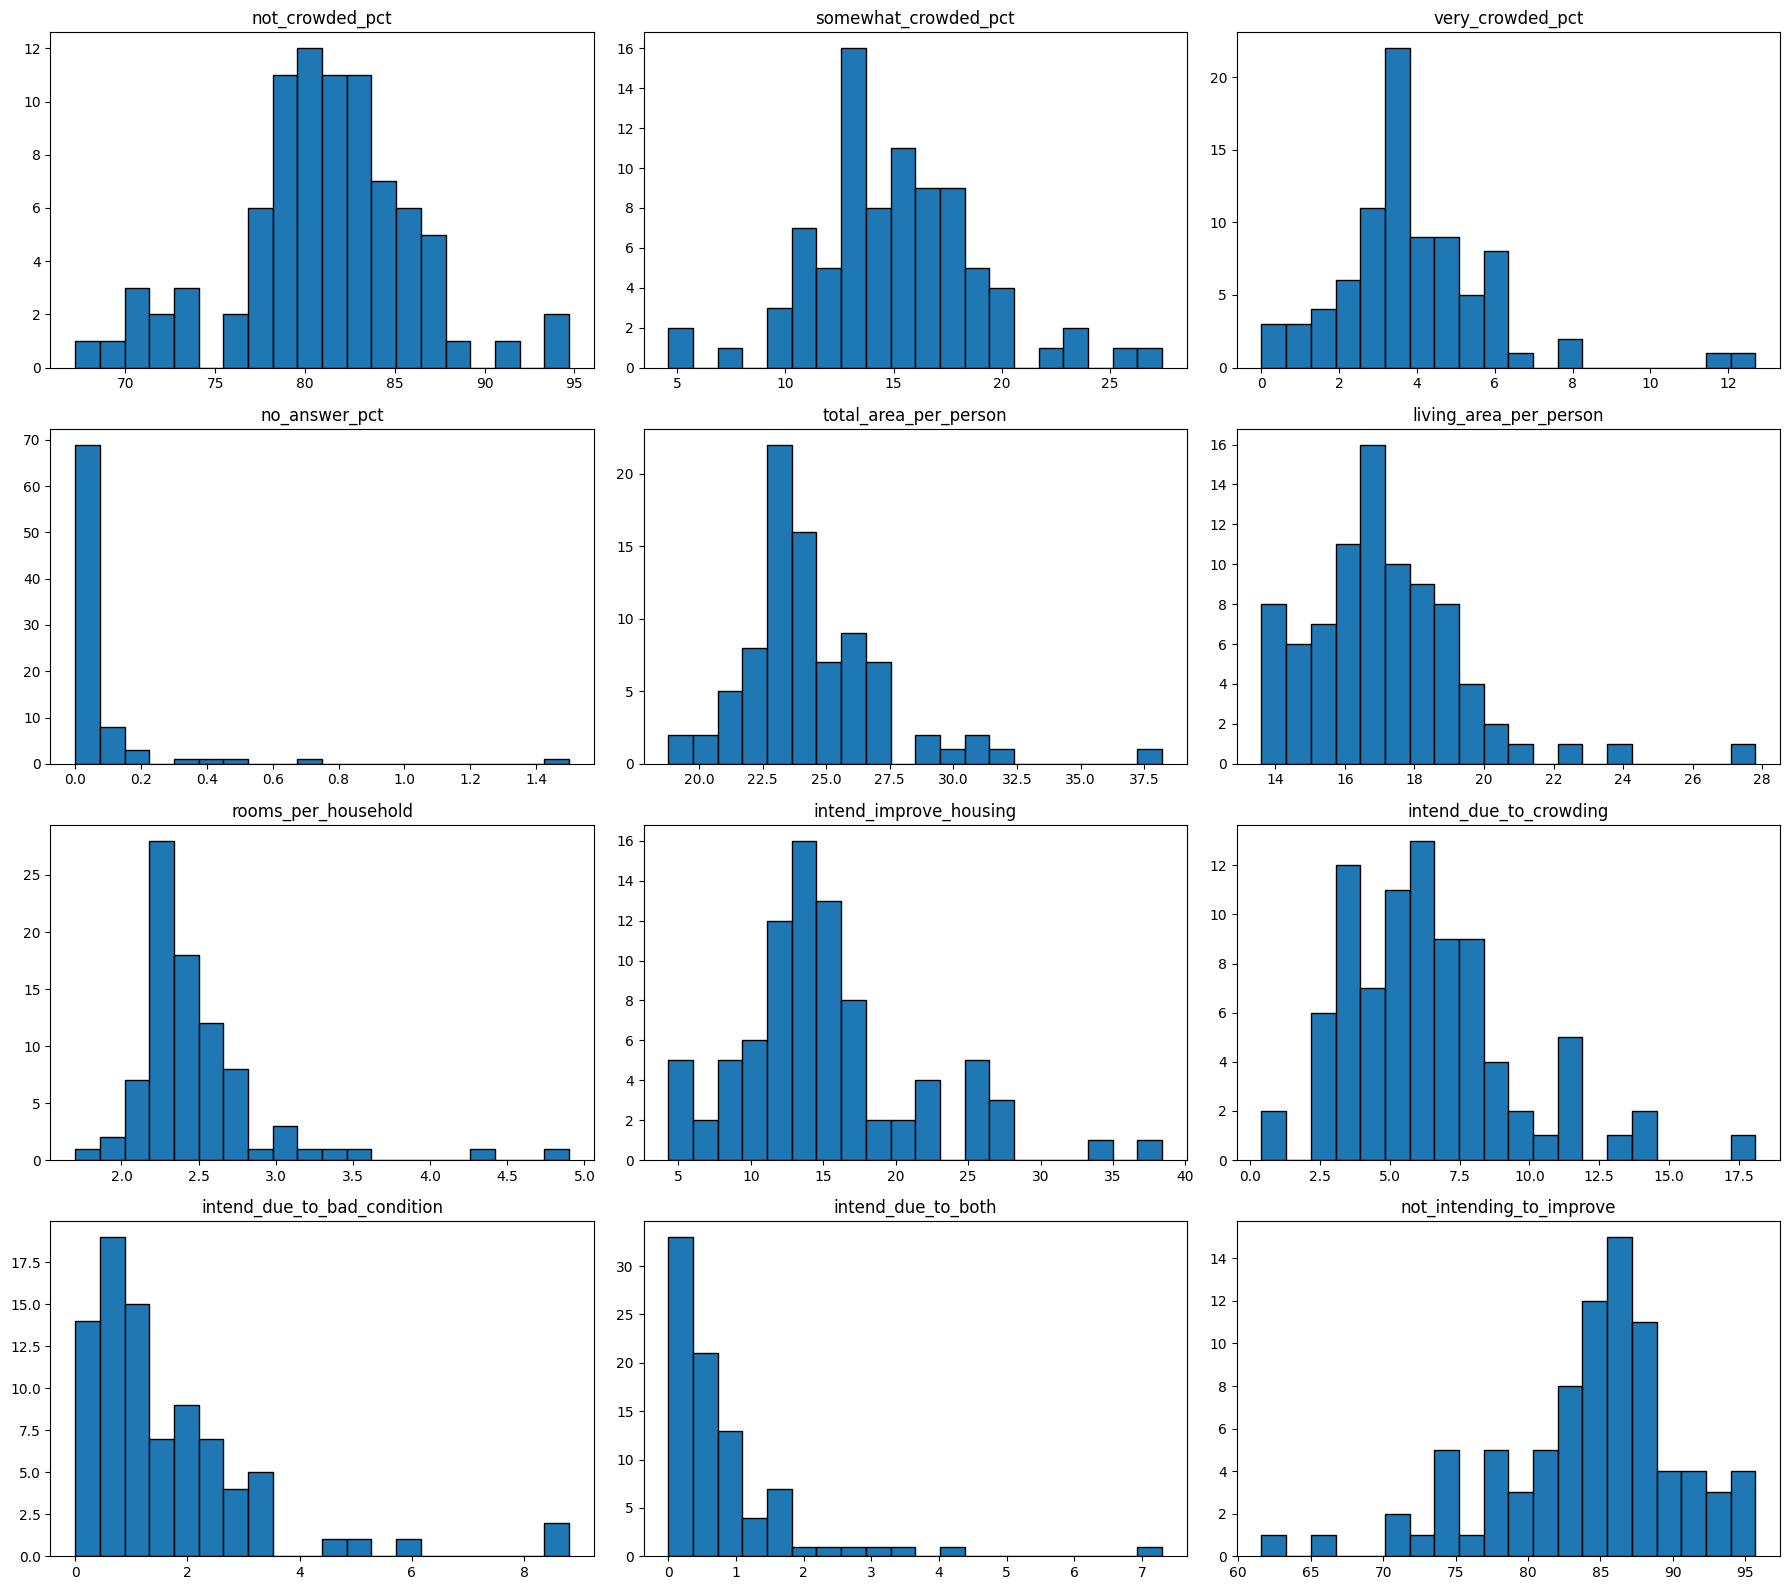

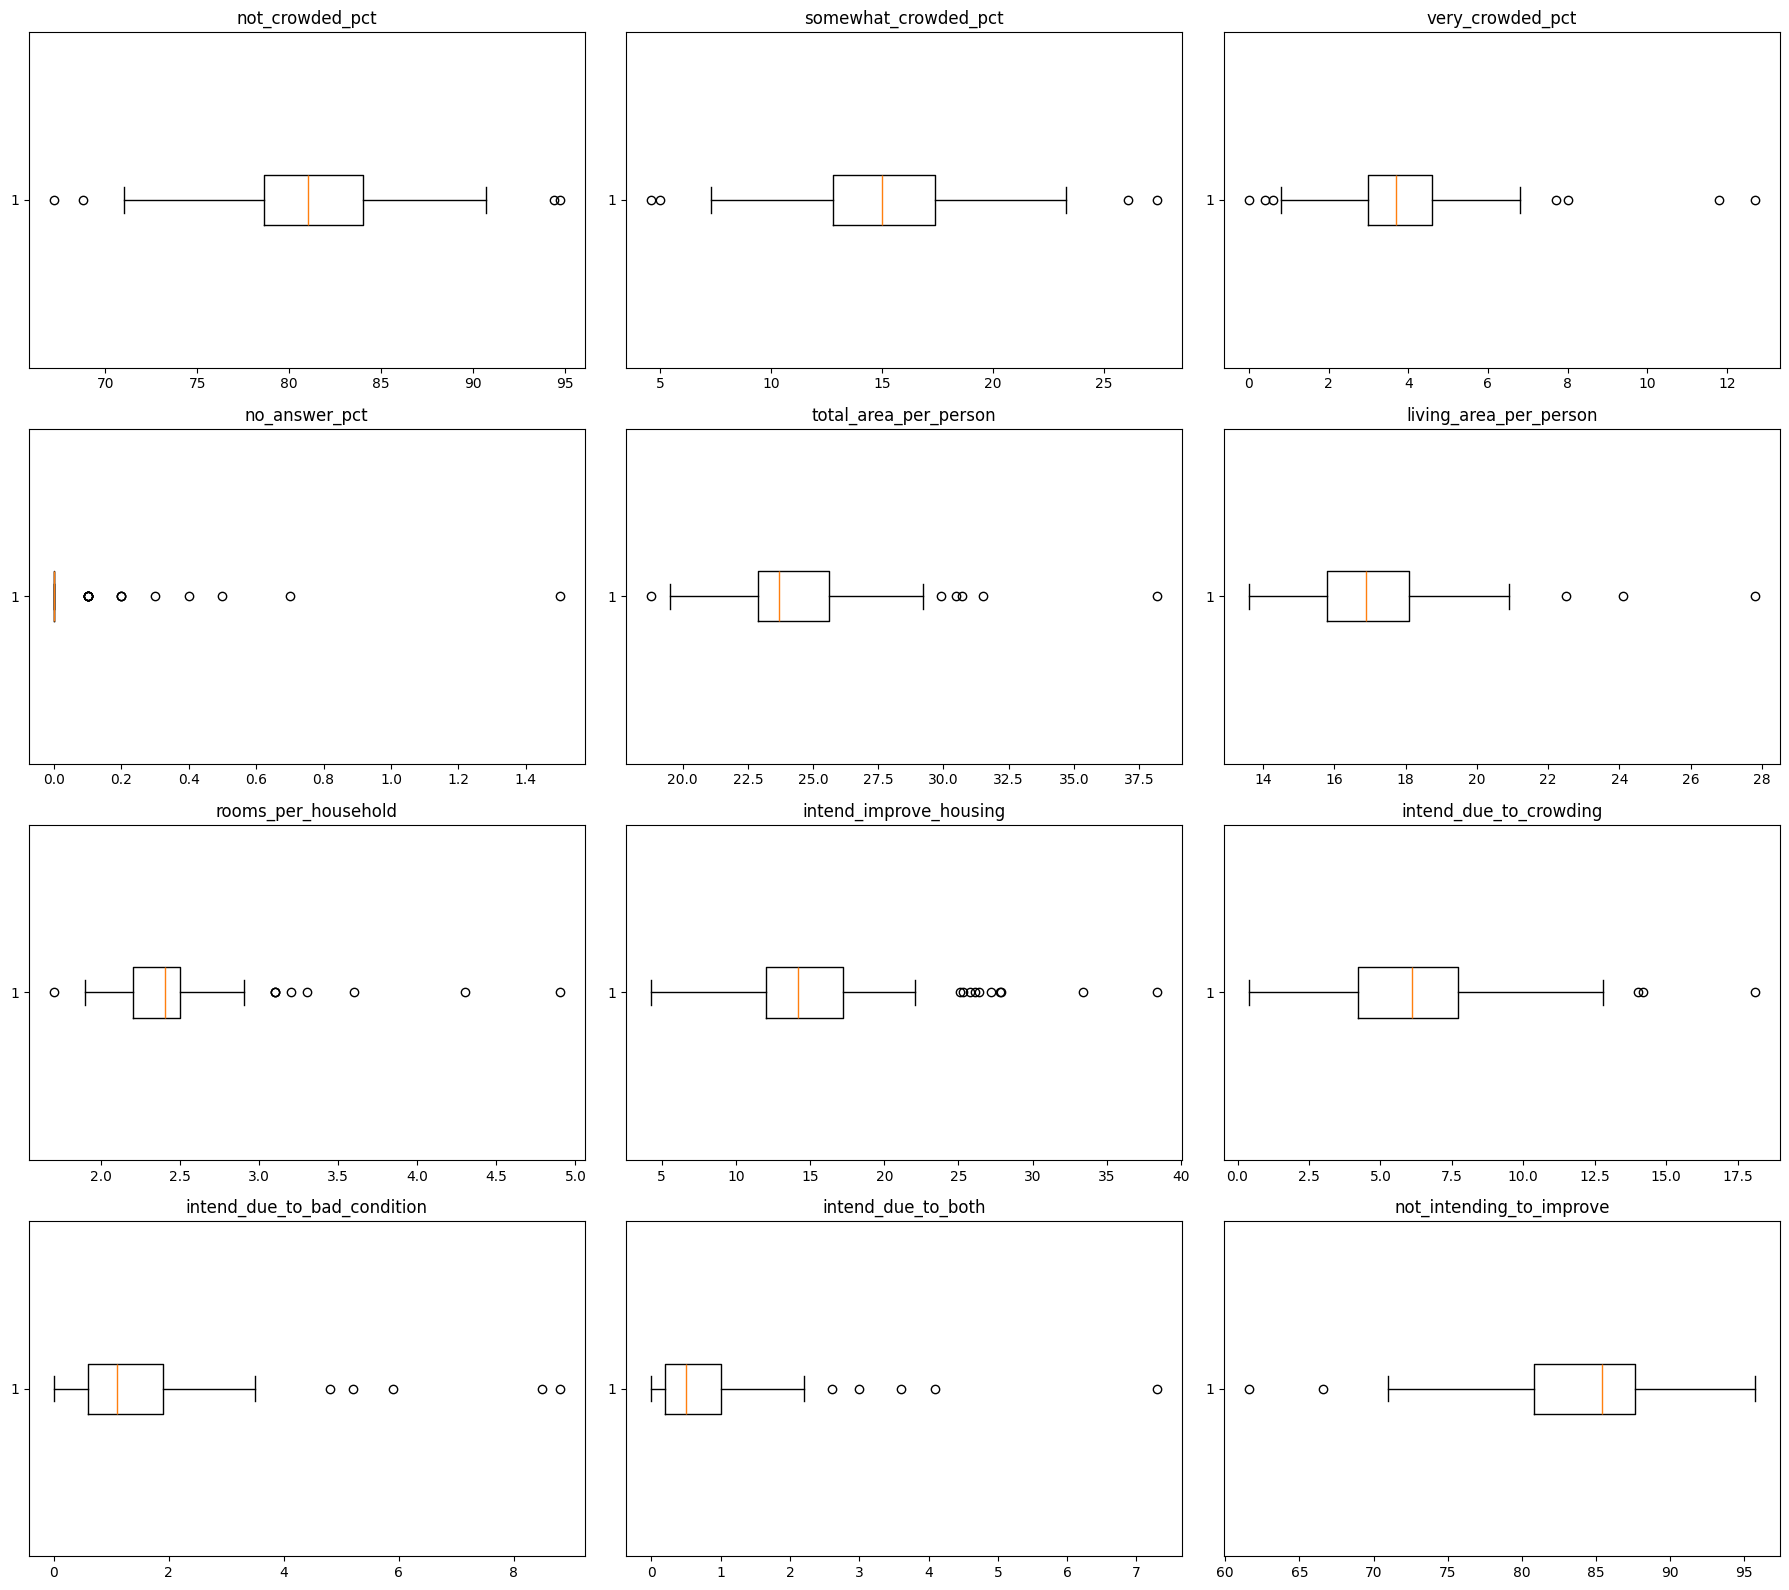

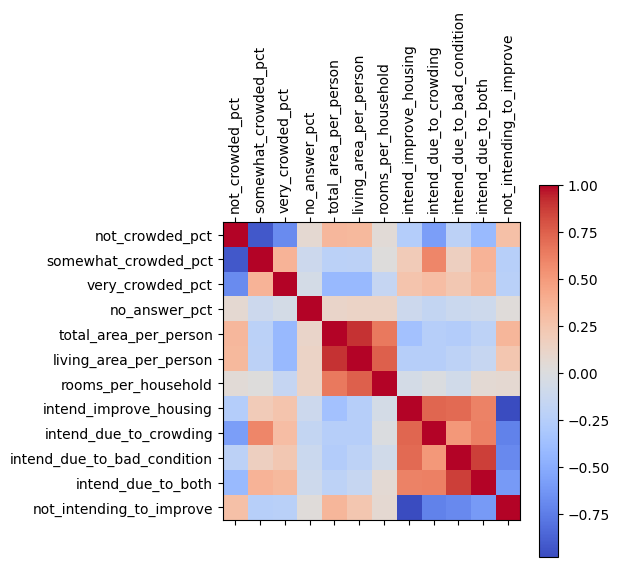

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/housing_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df_filtered = df[df["region_standard"].notna()].copy()

# 3. Convert selected planning-related columns to numeric
plan_cols = [
    "plan_dolevka",
    "plan_queue",
    "plan_resettle",
    "plan_buy_or_build",
    "plan_rent",
    "plan_other",
    "no_answer"
]

for col in plan_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors="coerce")

# 4. Drop planning-related columns for the current analysis
df_final = df_filtered.drop(columns=plan_cols)

# 5. Check duplicates
print("Number of duplicate rows:", df_final.duplicated().sum())

# 6. Check missing values
print("Total missing values:", df_final.isnull().sum().sum())

# 7. Number of rows and columns
print("Number of rows:", df_final.shape[0])
print("Number of columns:", df_final.shape[1])

# 8. Number of unique regions
print("Number of unique regions:", df_final["region_standard"].nunique())

# 9. Descriptive statistics
print(df_final.describe())

# 10. Top-5 regions by total area per person
print(
    df_final[["region_standard", "total_area_per_person"]]
    .sort_values(by="total_area_per_person", ascending=False)
    .head(5)
)

# 11. Top-5 regions by rooms per household
print(
    df_final[["region_standard", "rooms_per_household"]]
    .sort_values(by="rooms_per_household", ascending=False)
    .head(5)
)

# 12. Top-5 regions by intention to improve housing
print(
    df_final[["region_standard", "intend_improve_housing"]]
    .sort_values(by="intend_improve_housing", ascending=False)
    .head(5)
)

# 13. Histograms
numeric_cols = [
    "not_crowded_pct",
    "somewhat_crowded_pct",
    "very_crowded_pct",
    "no_answer_pct",
    "total_area_per_person",
    "living_area_per_person",
    "rooms_per_household",
    "intend_improve_housing",
    "intend_due_to_crowding",
    "intend_due_to_bad_condition",
    "intend_due_to_both",
    "not_intending_to_improve"
]

plt.figure(figsize=(18, 16))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    plt.hist(df_final[col], bins=20, edgecolor="black")
    plt.title(col)

plt.tight_layout()
plt.show()

# 14. Boxplots
plt.figure(figsize=(18, 16))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    plt.boxplot(df_final[col].dropna(), vert=False)
    plt.title(col)

plt.tight_layout()
plt.show()

# 15. Correlation matrix
corr = df_final[numeric_cols].corr()
plt.matshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

# EDA of `housing_standardized.csv`

## Data Description
- The dataset contains 85 observations across 85 regions.
- Time coverage: 2020.
- Key variables describe housing conditions, including crowding, living space, and housing improvement intentions.

---

## Data Types
- All variables are correctly formatted:
  - `year`: int64  
  - housing-related indicators: float64  
  - `region_standard`: object  

---

## Missing Values
- No missing values remain after preprocessing.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Share of non-crowded households: mean ~81%, minimum ~67%.  
- Total area per person: mean ~24.4 m², maximum ~38.2 m².  
- Rooms per household: mean ~2.5, maximum ~4.9.  
- Share planning to improve housing: mean ~15%, maximum ~38%.  
- Share not planning improvements: mean ~84%.  

These values indicate generally moderate living conditions with noticeable variation across regions.

---

## Top Regions by Living Space per Person
1. Republic of Ingushetia — 38.2 m²  
2. Nenets Autonomous Okrug — 31.5 m²  
3. Republic of Kalmykia — 30.7 m²  
4. Bryansk Oblast — 30.5 m²  
5. Republic of Dagestan — 29.9 m²  

These regions stand out in terms of available living space per person.

---

## Outliers
- Outliers were detected in several variables (e.g., crowding, rooms per household, housing intentions).  
- These values reflect real regional differences and were retained.  

---

## Distribution Patterns
- Most variables are approximately normally distributed or slightly skewed.  
- Some regions consistently appear as leaders in terms of living space and housing quality.  
- Higher shares of households planning to improve housing are concentrated in specific regions, suggesting unmet housing needs.

---

## Visual Analysis
- Histograms and boxplots were used to assess distributions.  
- A correlation heatmap was constructed to identify relationships between housing indicators.  

---

## Interpretation
- Housing conditions vary significantly across regions and reflect differences in living standards.  
- Crowding and limited space may indicate lower quality of life and higher socio-economic pressure.  
- The gap between objective indicators (space, rooms) and subjective intentions (plans to improve housing) suggests that perceived living conditions may differ from measured ones.  

These features provide an important structural dimension for clustering, complementing income, poverty, and health indicators.

---

## Conclusion
The dataset is clean and suitable for further analysis.

Housing variables contribute to a multidimensional understanding of regional inequality and are expected to play a meaningful role in clustering results.

In [2]:
df.to_csv("../../data/clean/housing_AfterEDA.csv", index=False)